In [2]:
cd tumbling_git

/share/nas2/pryder/tumbling_git


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from period_utils import *
import scipy.fft as s


In [4]:
freq = 1295e6
c= 299792458

## Autocorrelation

In [5]:
# spectrogram = np.load('/share/nas2/pryder/tumbling_git/exploring_parameters_results/spectrogram_intelsat_128_64.npy')
spec_0 = np.load('./spectrogram___intelsat_128cpi_1sampoverlap_tukey_128pad_106_strips.npy')
spec_1 = np.load('./spectrogram_a_intelsat_128cpi_1sampoverlap_tukey_128pad_106_strips.npy')
spec_2 = np.load('./spectrogram_b_intelsat_128cpi_1sampoverlap_tukey_128pad_106_strips.npy')
spec_3 = np.load('./spectrogram_c_intelsat_128cpi_1sampoverlap_tukey_128pad_106_strips.npy')

In [ ]:
combined_spec = np.hstack((spec_0, spec_1, spec_2, spec_3))
combined_spec.shape
spectrogram = combined_spec

In [49]:
combined_spec.shape

(256, 424)

In [51]:
max_velocity = c / (4 * 19.7e-3* (freq))
time = np.arange(spectrogram.shape[1])*19.7e-3*128
samp_rate = 424/time[-1]

#### Checking what the spectrogram looks like

In [1]:
plt.figure(figsize=(15, 5))
plt.imshow(10 * np.log10(combined_spec+1e-12)-np.max(10 * np.log10(combined_spec+1e-12)), aspect='auto', origin='lower', vmin=-25, vmax=0, extent= [0, time[-1], -max_velocity, max_velocity], cmap='inferno')
# plt.title("Micro-Doppler Spectrogram")
plt.xlabel("Time (s)")
plt.ylabel("Doppler Velocity (m/s)")
# plt.hlines(int(spectrogram.shape[0]/2+10), 0, 423, 'red')
plt.colorbar(label='Power (dB)')
plt.tight_layout()

NameError: name 'plt' is not defined

#### Performing autocorrelation on central row

In [9]:
chosen_row = spectrogram[int(spectrogram.shape[0]/2), :] #midpoint of y axis
row_autocorrelation = np.correlate(chosen_row, chosen_row, mode = 'full')
normalised_row_autocorrelation = row_autocorrelation/np.max(row_autocorrelation)

In [10]:
# finding peaks
delay = np.linspace(-time[-1], time[-1], spectrogram.shape[1]*2-1)
peaks_ind, _ = find_peaks(normalised_row_autocorrelation, height = 0.01, distance=6, threshold=0.04)
peaks_delay = delay[peaks_ind]
peaks_power = normalised_row_autocorrelation[peaks_ind]


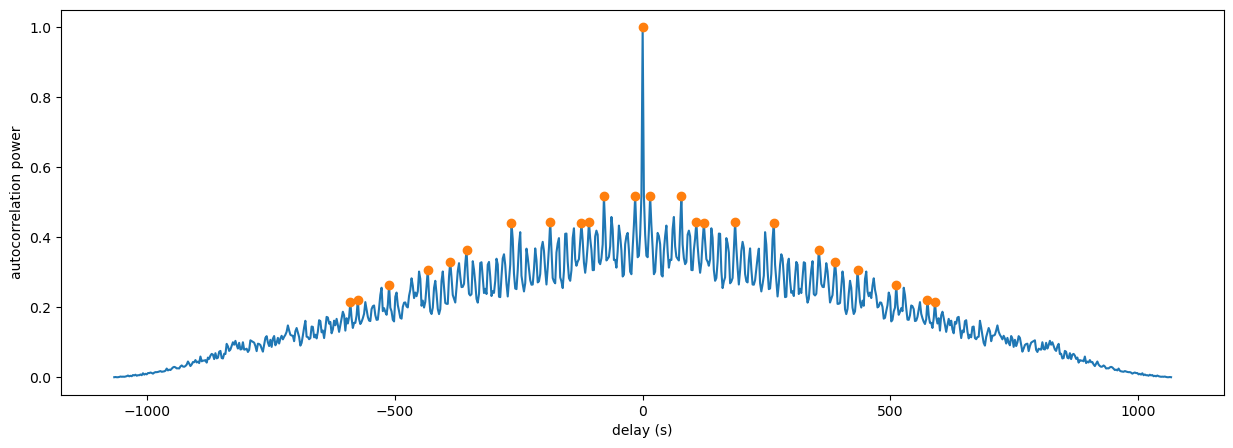

In [11]:
n = 14
plt.figure(figsize=(15, 5))
plt.plot(delay, normalised_row_autocorrelation)
plt.plot(peaks_delay, peaks_power, 'o')
# plt.plot(peaks_delay[n], peaks_power[n], 'o')
plt.xlabel('delay (s)')
plt.ylabel('autocorrelation power')
plt.show()

138


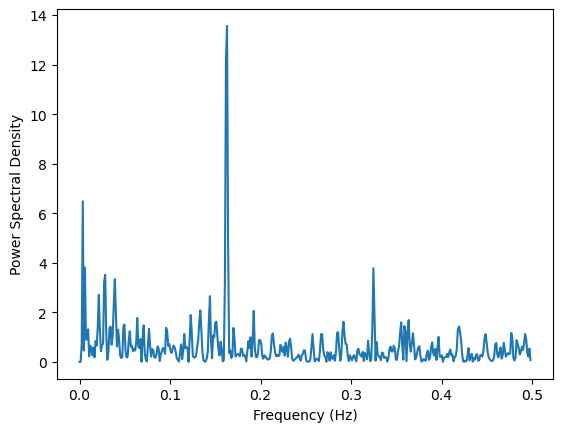

Dominant Frequency: 0.16 Hz
Corresponding Period: 6.1377 seconds


In [88]:
fft_res = np.abs(np.fft.fft(normalised_row_autocorrelation))
fft_res[0:2]=0 # removing zero delay signal
freqs = np.fft.fftfreq(len(normalised_row_autocorrelation))

half_index = len(fft_res) // 2
frequencies = freqs[:half_index]
psd = fft_res[:half_index]
dominant_freq = frequencies[np.argmax(psd)]
print(np.argmax(psd))
corresponding_period = 1 / dominant_freq
plt.plot(frequencies, psd)
# plt.scatter(dominant_freq, 20)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power Spectral Density')
plt.show()
print(f"Dominant Frequency: {dominant_freq:.2f} Hz")
print(f"Corresponding Period: {corresponding_period:.4f} seconds")

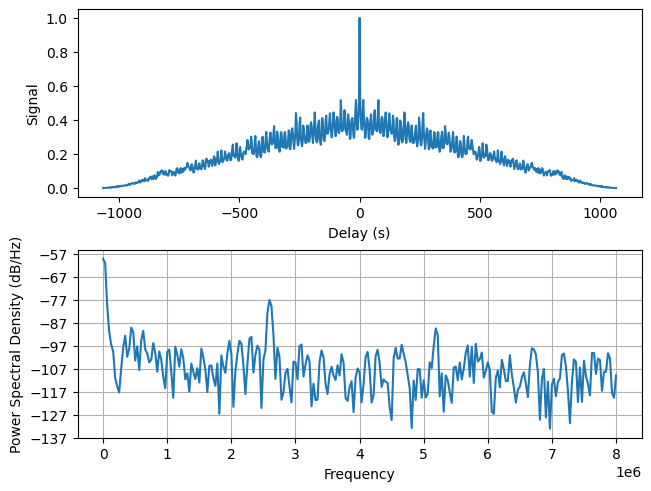

In [75]:
fig, (ax0, ax1) = plt.subplots(2, 1, layout='constrained')
ax0.plot(delay, normalised_row_autocorrelation)
ax0.set_xlabel('Delay (s)')
ax0.set_ylabel('Signal')
ax1.psd(normalised_row_autocorrelation, NFFT=512, Fs=16e6)

plt.show()

In [39]:
np.argmax(fft_res)

np.int64(0)

In [310]:

differences = []
for i in range(len(peaks_delay)-1):
    difference = peaks_delay[i+1]-peaks_delay[i]
    differences.append(difference)

print(np.unique(np.round(np.unique(differences), 15)))
_, diffs_count = np.unique(differences, return_counts=True)
print(diffs_count)


[ 5.0432  5.0432  5.0432  7.5648  7.5648  7.5648 10.0864 10.0864 10.0864
 12.608  12.608  12.608  15.1296 15.1296 15.1296 17.6512 17.6512 17.6512]
[ 3  9 12 22 18 24  4  7  5 12  5  1 39  1  2  1 20  1]


In [315]:
long_period = 78.16959999999995
short_period = 15.129600000000096

long_period/short_period

5.1666666666666305

#### Now performing autocorrelation row wise on spectrogram. 

In [13]:
autocorrelation = np.zeros((spectrogram.shape[0], spectrogram.shape[1]*2-1))
for n in range(spectrogram.shape[0]):
    row = spectrogram[n, :]
    autocorrelation[n, :] = np.correlate(row, row, mode='full')

# autocorrelation = np.sum(autocorrelation, axis=1)

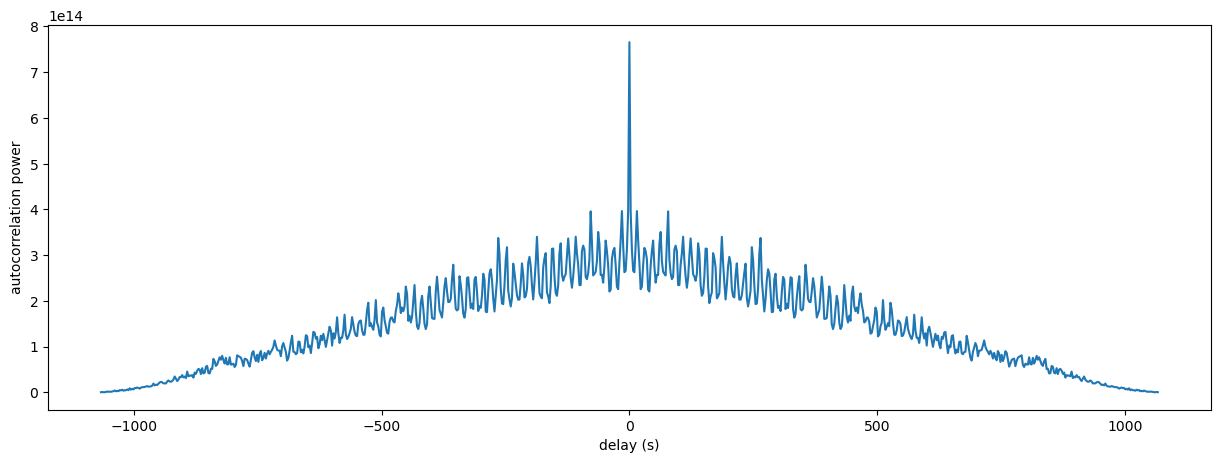

In [15]:
#lets check i've got this right
delay = np.linspace(-time[-1], time[-1], spectrogram.shape[1]*2-1)
plt.figure(figsize=(15, 5))
plt.plot(delay, autocorrelation[int(spectrogram.shape[0]/2)])
plt.xlabel('delay (s)')
plt.ylabel('autocorrelation power')
plt.show()

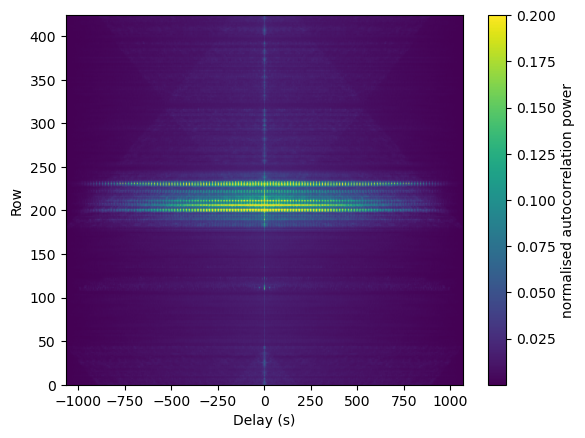

In [16]:
plt.imshow(autocorrelation/np.max(autocorrelation), origin='lower', vmax=0.2,  extent = [-time[-1], time[-1], 0, spectrogram.shape[1]], aspect='auto')
plt.xlabel('Delay (s)')
plt.ylabel('Row')
plt.colorbar(label='normalised autocorrelation power')
plt.show()

In [17]:
summed_autocorrelation = np.sum(autocorrelation, axis=0)
normalised_autocorrelation = summed_autocorrelation/np.max(summed_autocorrelation)
# finding peaks
peaks_ind, _ = find_peaks(normalised_autocorrelation, height = 0.01, distance=6, threshold=0.04)
peaks_delay = delay[peaks_ind]
peaks_power = normalised_autocorrelation[peaks_ind]

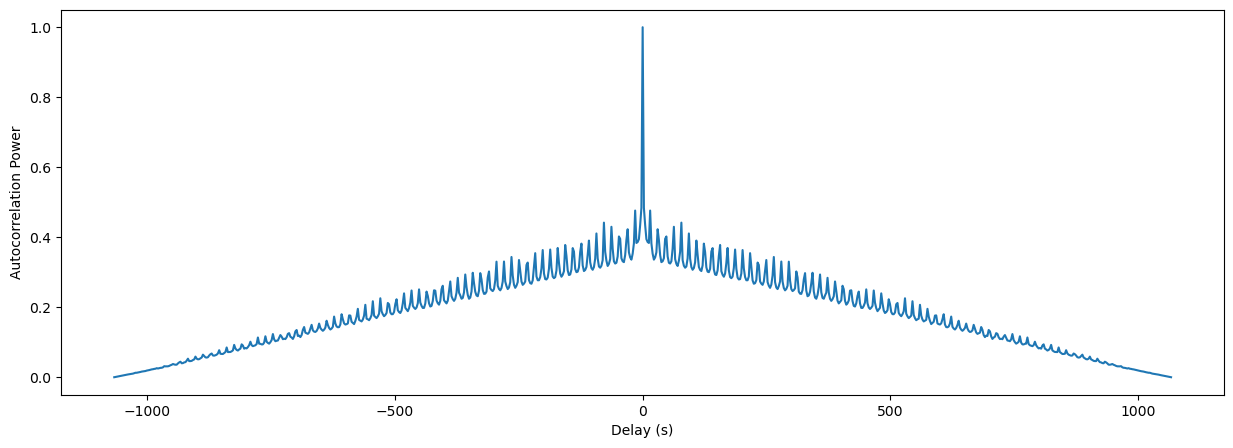

In [18]:
plt.figure(figsize=(15,5))
plt.plot(delay, normalised_autocorrelation)
# plt.plot(peaks_delay, peaks_power, 'o')
plt.xlabel('Delay (s)')
plt.ylabel('Autocorrelation Power')
plt.show()

137


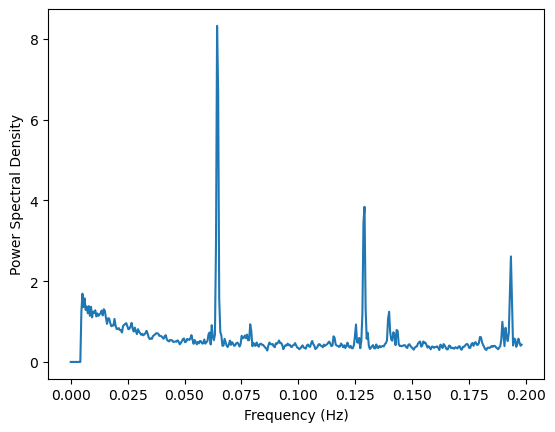

Dominant Frequency: 0.06 Hz
Corresponding Period: 15.5530 seconds


In [54]:
fft_res = np.abs(np.fft.fft(normalised_autocorrelation))
fft_res[0:10]=0 # removing zero delay signal
freqs = np.fft.fftfreq(len(normalised_autocorrelation), d=1/samp_rate )

half_index = len(fft_res) // 2
frequencies = freqs[:half_index]
psd = fft_res[:half_index]
dominant_freq = frequencies[np.argmax(psd)]
print(np.argmax(psd))
corresponding_period = 1 / dominant_freq
# frequencies = np.linspace(ls_rowwise_freq[0], ls_rowwise_freq[-1], len(frequencies))
# dominant_freq = frequencies[np.argmax(psd)]
# corresponding_period = 1 / dominant_freq
plt.plot(frequencies, psd)
# plt.scatter(dominant_freq, 20)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power Spectral Density')
plt.show()
print(f"Dominant Frequency: {dominant_freq:.2f} Hz")
print(f"Corresponding Period: {corresponding_period:.4f} seconds")

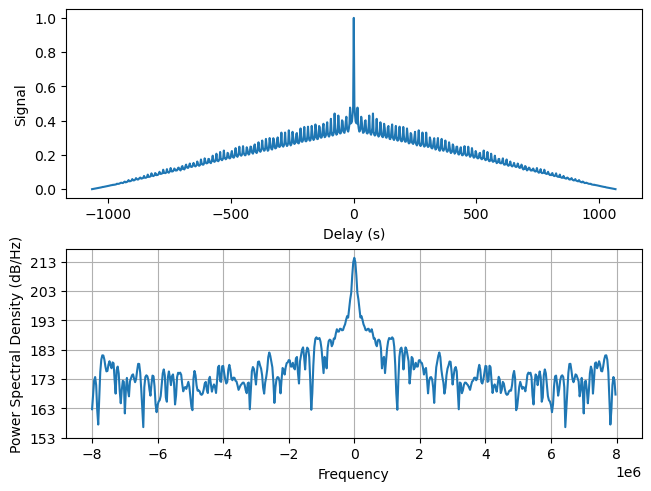

In [85]:
fig, (ax0, ax1) = plt.subplots(2, 1, layout='constrained')
ax0.plot(delay, normalised_autocorrelation)
ax0.set_xlabel('Delay (s)')
ax0.set_ylabel('Signal')
ax1.psd(autocorrelation, NFFT=512, Fs=16e6, sides='twosided')

plt.show()

In [341]:
differences = []
for i in range(len(peaks_delay)-1):
    difference = peaks_delay[i+1]-peaks_delay[i]
    differences.append(difference)

print(np.unique(np.round(np.unique(differences), 15)))
_, diffs_count = np.unique(differences, return_counts=True)
print(diffs_count)


[15.1296 47.9104 47.9104 63.04   63.04   63.04   78.1696 78.1696]
[16  1  1  2  1  1  1  1]


## Lomb-Scargle Periodogram

In [31]:
from astropy.timeseries import LombScargle

In [34]:
summed_spec = np.sum(spectrogram, axis=0)

vel = np.linspace(-max_velocity, max_velocity, 256)

In [10]:
vel_tip = vel[np.argmax(np.sum(spectrogram, axis=1))]
vel_tip

np.float64(0.2649795587764534)

In [35]:
frequency, power = LombScargle(time, summed_spec).autopower(method = 'slow', nyquist_factor=1)

In [36]:
ls_rowwise_pow = np.zeros((len(power),  spectrogram.shape[0]))

for i in range(spectrogram.shape[0]):
    # print(i)
    row_freq, row_pow = LombScargle(time, spectrogram[i, :]).autopower(method='slow', nyquist_factor=1)
    ls_rowwise_freq = row_freq
    ls_rowwise_pow[:, i] = row_pow

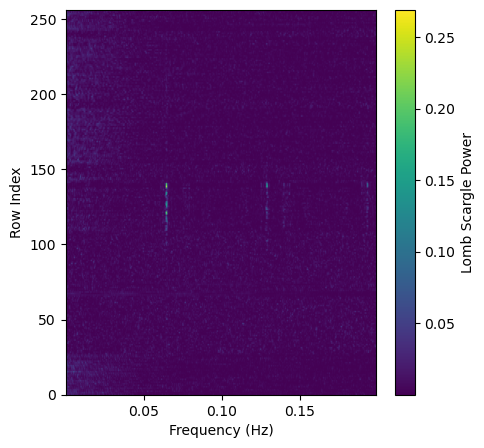

In [14]:
plt.figure(figsize=(5, 5))
plt.imshow(ls_rowwise_pow.T, origin='lower', extent=[ls_rowwise_freq[0], ls_rowwise_freq[-1], 0, 256], aspect='auto')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Row Index')
plt.colorbar(label='Lomb Scargle Power')

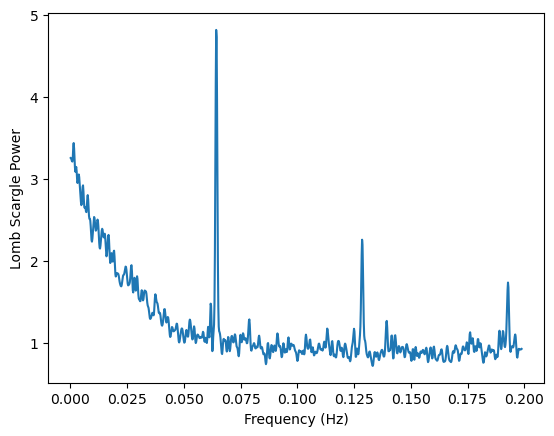

In [15]:
ls_rowwise_summed = np.sum(ls_rowwise_pow, axis=1)
plt.plot(ls_rowwise_freq, ls_rowwise_summed)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Lomb Scargle Power')
plt.show()

In [26]:
peak_f, peak_T = peakfindergeneral(ls_rowwise_freq, ls_rowwise_summed, 0.9)

Peak frequencies (Hz): [0.06422055]
Corresponding periods (s): [15.57134015]


Text(0.5, 0, 'Frequency (Hz)')

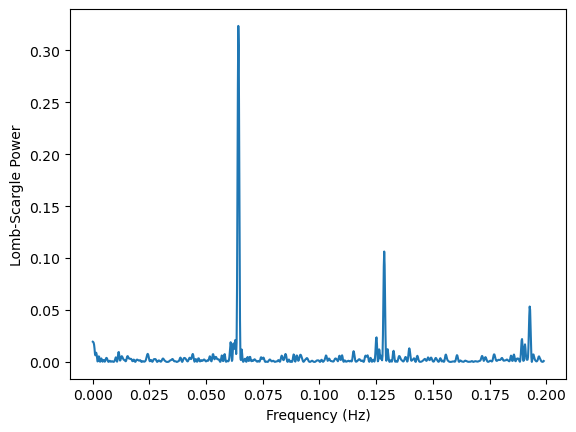

In [18]:
fig, ax = plt.subplots()
ax.plot(frequency, power)
# ax.set_xlim(0.05, 0.075)
plt.ylabel('Lomb-Scargle Power')
plt.xlabel('Frequency (Hz)')

In [19]:
from scipy.optimize import curve_fit

def gaussian(x, A, mu, sigma):
    beamwidth = 0.106
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2))

def single_gaussian_fitter(f, p, init_mu, init_sigma, target_name):
    
    # power_range = np.sum(data[:, start_range:end_range], axis=1)
    popt, pcov = curve_fit(gaussian, f, p, p0=[max(p), init_mu, init_sigma])
    A, mu, sigma = popt

    errors = np.sqrt(np.diag(pcov))
    mu_err = errors[1]
    # sigma_err = errors[2]

    x_fit = f
    y_fit = gaussian(f, *popt)
    print('Peak offset = ', mu, 'Hz')
    print('Error = ±', mu_err, 'Hz')
    print('Width = ', sigma, 'Hz')
    print('percentage error', sigma/frequency[np.argmax(power)]*100, '%')
    plt.plot(f, p, label = 'observation')
    plt.plot(x_fit, y_fit, label="Gaussian fit", color ='r')
    plt.xlim(0.05, 0.075)
    plt.xlabel('Frequency')
    plt.ylabel('Power')
    plt.title(target_name)
    plt.legend()
    plt.show()

Peak offset =  0.06426939907499521 Hz
Error = ± 6.496801995959935e-06 Hz
Width =  0.0003527810727432745 Hz
percentage error 0.5493274080751146 %


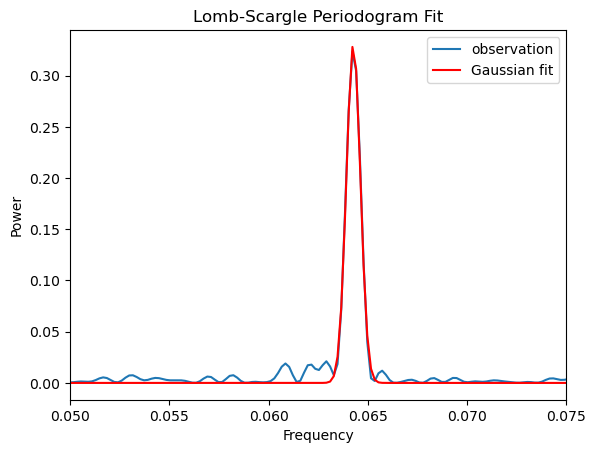

In [20]:
single_gaussian_fitter(frequency, power, frequency[np.argmax(power)], 0.0001, 'Lomb-Scargle Periodogram Fit')

In [73]:
peaks =find_peaks(power, height=np.max(power)*0.1)
peak_freqs = frequency[peaks[0]]
print("Peak frequencies (Hz):", peak_freqs)
print("Corresponding periods (s):", 1/peak_freqs[0])

Peak frequencies (Hz): [0.06422055 0.12853485 0.19266164]
Corresponding periods (s): 15.571340145985403


In [84]:
((0.5493274080751146)/100)*15.57134015

0.08553763924855465

In [22]:
v = vel_tip
print('Corresponding lengths (cm):', ((v*(1/peak_freqs))/(2*np.pi)*100)[0])

Corresponding lengths (cm): 2.855161375833988


In [23]:
((v*((1/peak_freqs[0])+0.09))/(2*np.pi)*100) - ((v*(1/peak_freqs[0]))/(2*np.pi)*100)

np.float64(0.01650240258166269)

TypeError: 'NoneType' object is not callable

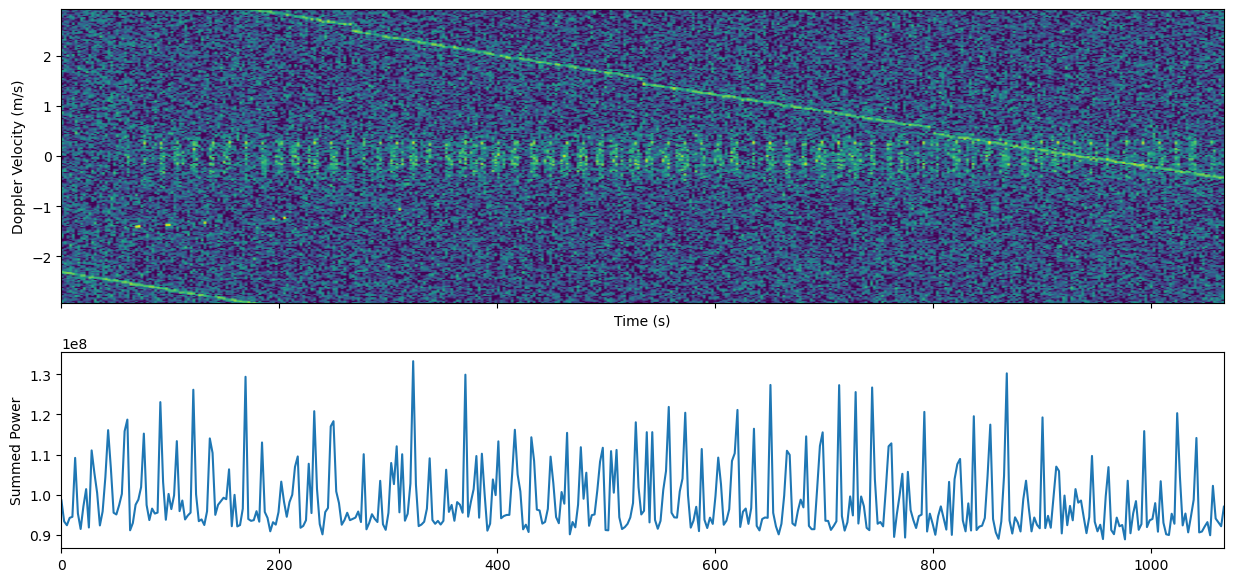

In [24]:
# --- 1. Setup the figure and subplots ---
# sharex=True aligns the x-axes perfectly
# gridspec_kw adjusts the height ratio so the spectrogram is taller
fig, (ax2, ax1) = plt.subplots(
    2, 1, figsize=(15, 7), sharex=True, gridspec_kw={"height_ratios": [3, 2]}
)

# --- 2. Top Plot: Line plot (summed_spec) ---
ax1.plot(time, summed_spec)
ax1.set_ylabel("Summed Power")  # Add a label for clarity
# ax1.set_title("Micro-Doppler Spectrogram Analysis") # Optional title


im = ax2.imshow(10 * np.log10(combined_spec+1e-12)-np.max(10 * np.log10(combined_spec+1e-12)), aspect='auto', origin='lower', vmin=-25, vmax=0, extent= [0, time[-1], -max_velocity, max_velocity])

ax2.set_xlabel("Time (s)")
ax2.set_ylabel("Doppler Velocity (m/s)")
im.colorbar(label='Power (dB)', ax=ax2)




plt.tight_layout()
plt.show()

In [25]:
print(power.max())

0.3235774758557922


In [26]:
ls = LombScargle(time, summed_spec)

In [27]:
fap = ls.false_alarm_probability(power.max(), method='bootstrap')
fap

np.float64(0.0)

In [28]:
probabilities = [0.1, 0.05, 0.01]
ls.false_alarm_level(probabilities)


array([0.04832958, 0.05174   , 0.05938002])